### Practica - Aparato de conductividad termica. 

El aparato usado permitira estudiar la conductividad termica de cinco materiales:

La ecuacion que da la cantidad de calor conducida atraves de un material esta dada por: 
$$
\Delta Q = k A \Delta T \frac{\Delta t}{h}
$$
donde: 
- $\Delta Q$ es la energia total conducida.
- $A$ es el area que transversa la conduccion.
- $\Delta T$ es el cambio en temperatura.
- $k$ es la conductividad termica del material, que es lo que buscamos. 

In [15]:
# LIBRERIAS
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scienceplots

#### Experimento
Para nuestro caso, tendremos el aparato que conducira calor a una lamina de un cierto material. Arriba de la lamina de dicho material, yacera un cilindro de hielo.

En condiciones ideales, el aparato estara a $100 \degree$ C mientras que el cilindro de hielo estara a $0 \degree$ C. A medida que el cilindro se derrite, se recolectara y medira la cantidad de agua recogida (un volumen) y con ello podremos calcular el calor transferido. 

De alli podremos calcular la conductividad termica de acuerdo a la siguiente ecuacion: 

$$
k = \left( \frac{\text{cal cm}}{\text{cm}^2 \text{ sec}} \right) = \frac{(\text{mass of melted ice}) (80 \text{ cal/gm}) (\text{thickness of material})}{(\text{area of ice}) (\text{time during which ice melted}) (\text{temp. differential})}
$$
o 
$$
k = \frac{m \cdot L_f \cdot \Delta x}{A \cdot t \cdot \Delta T}
$$

In [17]:
plt.style.use(['science', 'ieee'])

In [18]:
# constantes experimento
dT=100 # Rango de temperatura. 
Lf=80.0 # Calor latente de fusion del hielo. 
rho_agua=1.0 # Densidad del agua (g/ml)

#Incertidumbres
err_V=0.5
err_t=0.5
err_h=0.01
err_d=0.05

In [19]:
#Datos de experimento
#'Nombre':[Espesor (h), Diametro(d), Tiempo(t), Volumen (V)]
datos_lab={
    'Vidrio': [0.5, 5.96, 1200, 103, 20],
    'Masonita':[0.54, 5.7, 1200, 507, 20], 
    'Madera':[0.47, 5.61, 1200, 480, 20], 
    'Acrilico':[0.5, 4.88, 1200, 643, 20], 
    'Yeso':[0.51, 4.48, 1200, 306, 7]
}
resultados=[]

for mat, val in datos_lab.items():
    h, d, t_amb, t_vap, V=val

    # calculo de areas y masas
    area=np.pi*(d/2)**2
    m_recolectada=V*rho_agua

    R_total=m_recolectada/t_vap
    R_ambiental=m_recolectada/t_amb

    R0=R_total-R_ambiental

    #calculo de k
    k=(R0*Lf*h)/(area*dT)

    rel_V = (err_V / V)**2
    rel_h = (err_h / h)**2
    rel_t = (err_t / t_vap)**2
    rel_d = (2 * err_d / d)**2 
    
    dk = k * np.sqrt(rel_V + rel_h + rel_t + rel_d)
    
    resultados.append({
        'Material': mat, 
        'k (cal·cm/cm²·s·°C)': k, 
        'Error Absoluto': dk,
        'Error Relativo %': (dk/k)*100
    })

In [20]:
df=pd.DataFrame(resultados)
print(df.to_string(index=False))

Material  k (cal·cm/cm²·s·°C)  Error Absoluto  Error Relativo %
  Vidrio             0.002545        0.000093          3.647031
Masonita             0.000386        0.000014          3.573087
  Madera             0.000380        0.000014          3.737005
Acrilico             0.000309        0.000012          3.801998
    Yeso             0.000441        0.000034          7.737845


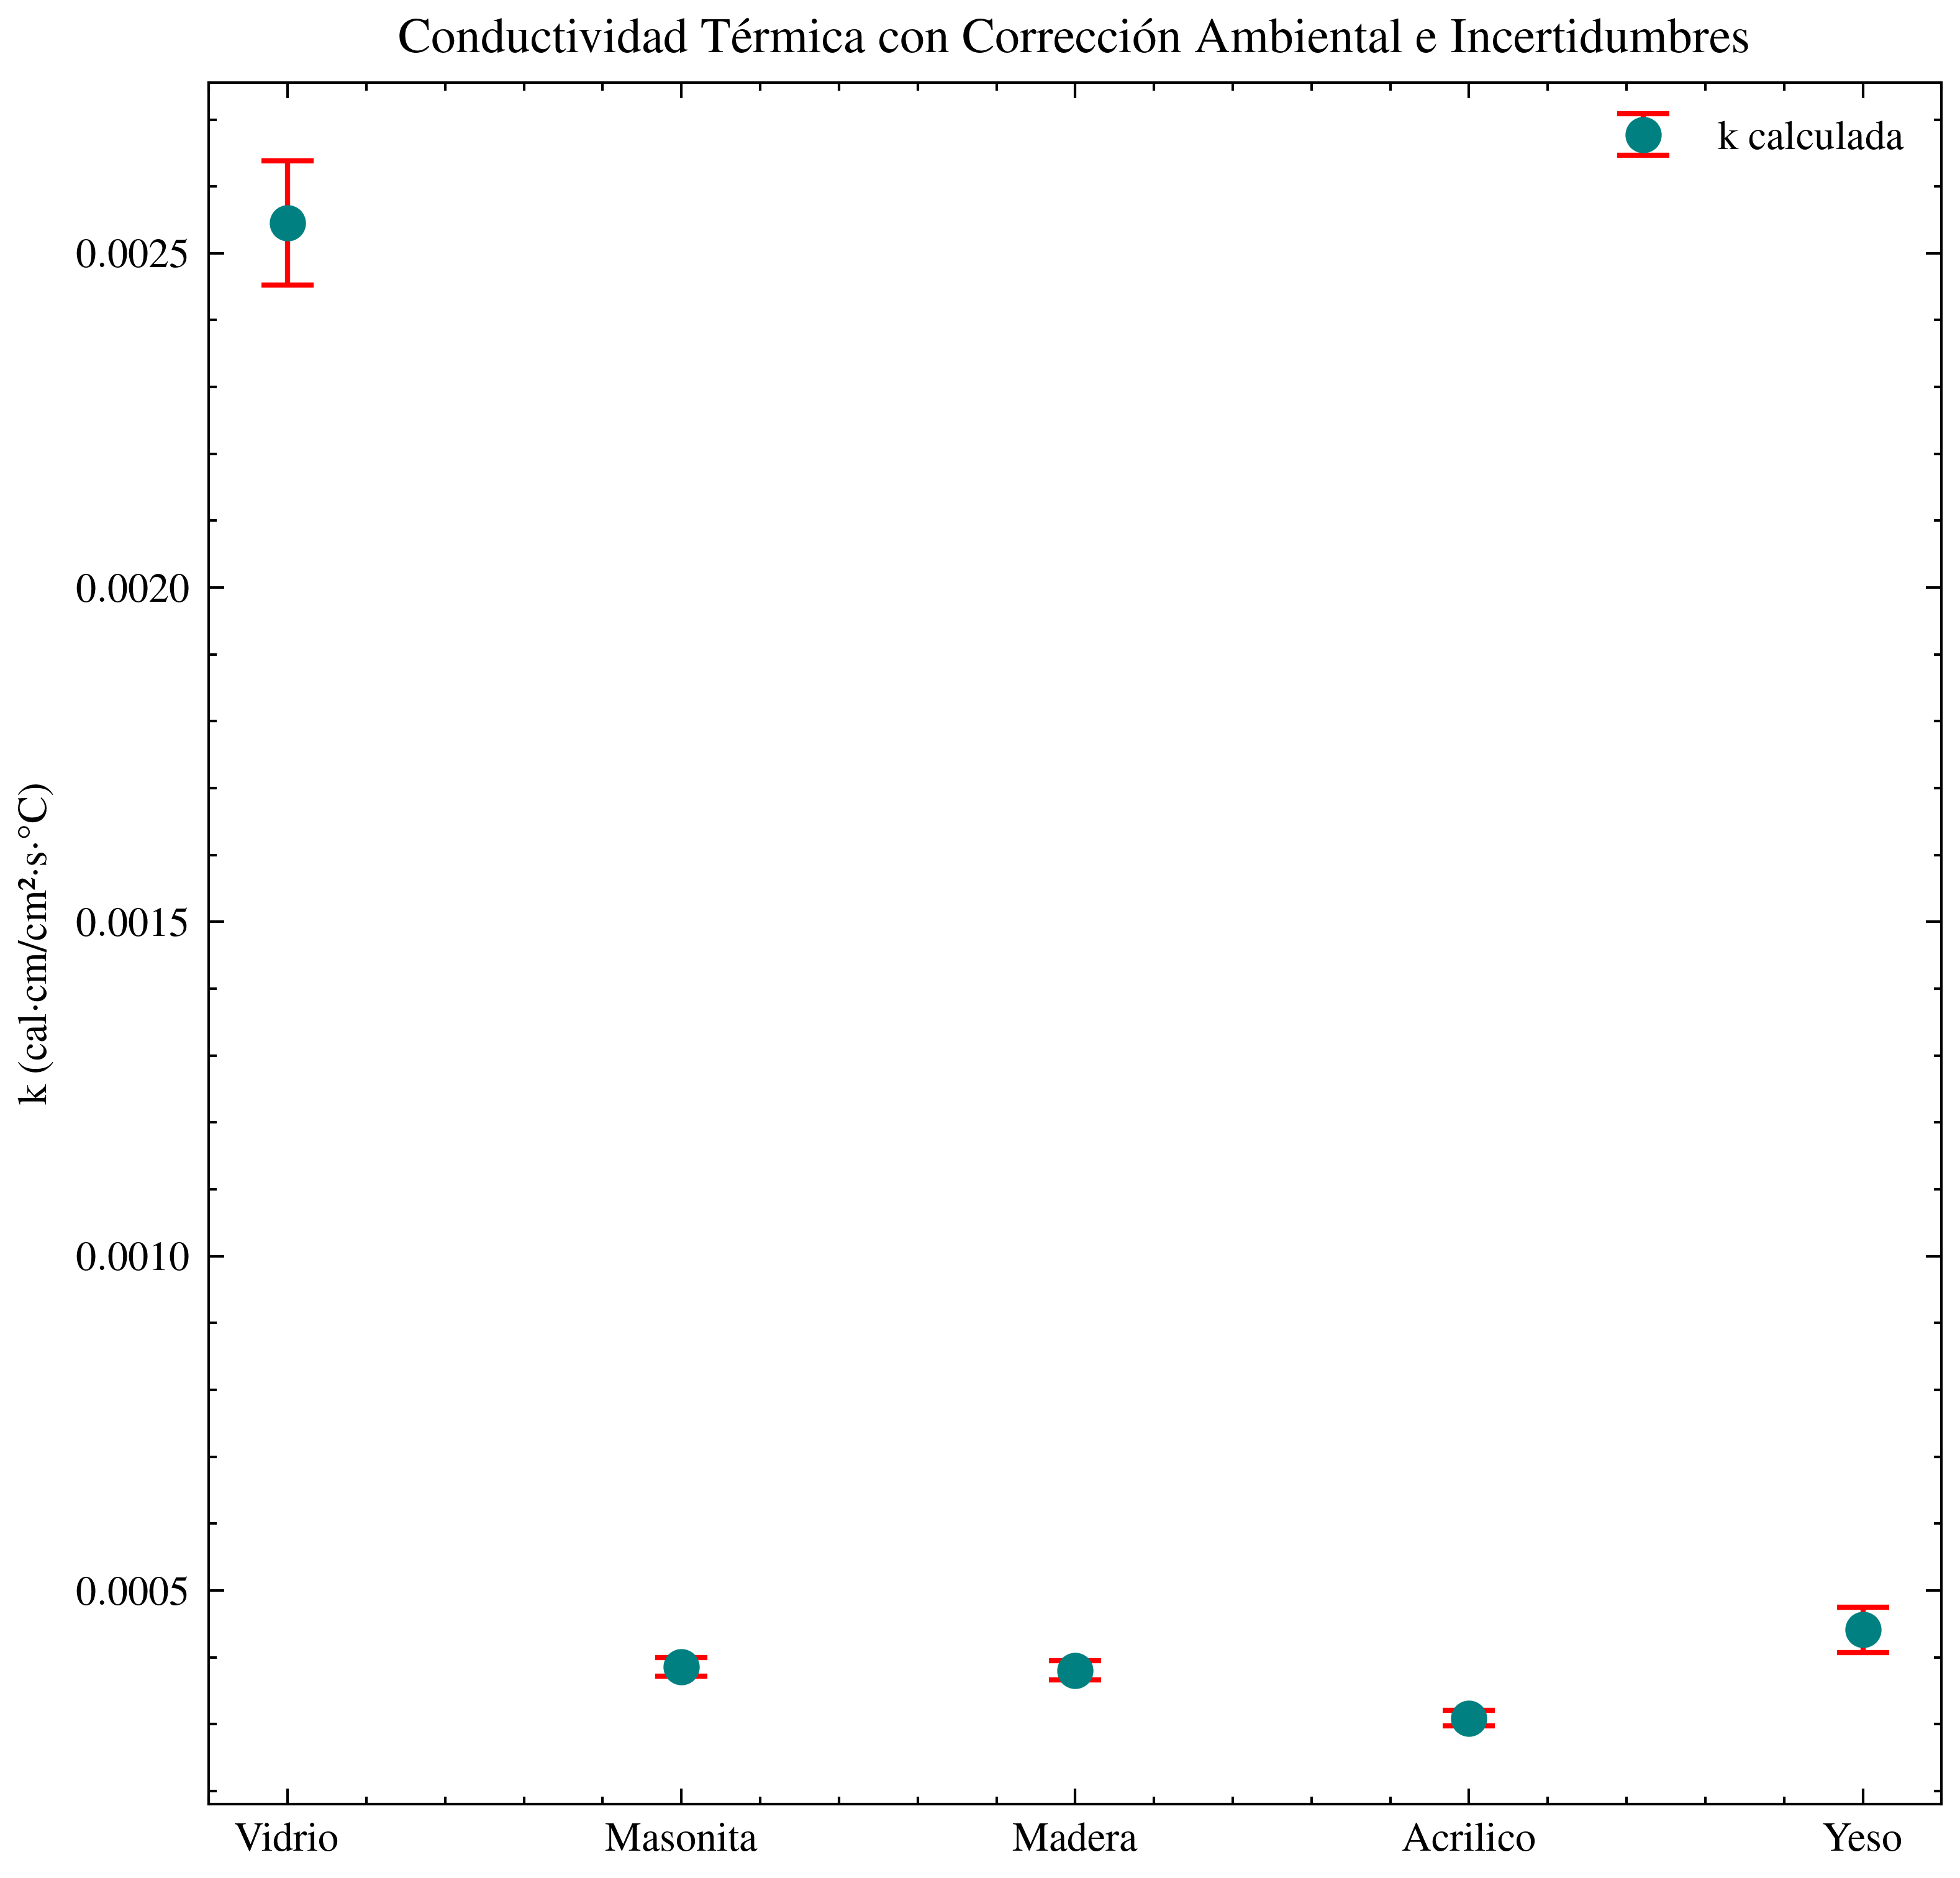

In [24]:
plt.figure(figsize=(6, 6))
plt.errorbar(df['Material'], df['k (cal·cm/cm²·s·°C)'], yerr=df['Error Absoluto'], 
             fmt='o', capsize=5, color='teal', ecolor='red', label='k calculada')
plt.ylabel('k (cal·cm/cm²·s·°C)')
plt.title('Conductividad Térmica con Corrección Ambiental e Incertidumbres')
#plt.grid()
plt.legend()
plt.show()